# Analisis de visitas y ventas a Showz 2017-2018


# Introducción del Proyecto
Este proyecto analiza el comportamiento de los usuarios y la rentabilidad de las campañas de marketing en Showz, una empresa de venta de entradas para eventos.

Se dispone de registros de visitas al sitio web, datos de pedidos y estadísticas de gastos publicitarios entre enero de 2017 y diciembre de 2018. El objetivo es comprender:

Cómo y cuándo los clientes usan el servicio.

En qué momento comienzan a comprar.

Cuánto aporta cada cliente a la compañía (LTV).

Cuándo los ingresos compensan el costo de adquisición (CAC).

El análisis incluye:

Preparación de datos para garantizar formatos y tipos adecuados.

Cálculo de métricas clave de uso, ventas y marketing, incluyendo ROMI y segmentación por dispositivos y fuentes de adquisición.

Visualización de tendencias y comparaciones para detectar patrones y oportunidades de optimización.

Conclusiones y recomendaciones para optimizar la inversión en marketing y priorizar las fuentes más rentables.


In [42]:
import pandas as pd

In [43]:
df_visitas = pd.read_csv('/datasets/visits_log_us.csv')
df_ventas = pd.read_csv('/datasets/orders_log_us.csv')
df_costos = pd.read_csv('/datasets/costs_us.csv')

In [44]:
print('df_visitas \n', df_visitas.head())
print('df_ventas \n', df_ventas.head())
print('df_costos \n', df_costos.head())


df_visitas 
     Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
df_ventas 
                 Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
df_costos 
    source_id          dt  costs
0          1  2017-06-01  75.20
1          1  20

In [45]:
df_visitas['Start Ts'] = pd.to_datetime(df_visitas['Start Ts'])
df_visitas['End Ts'] = pd.to_datetime(df_visitas['End Ts'])

## Parte 1 Analisis de visitas

In [46]:
#Numero de visitantes
df_visitas['sesiones_year'] = df_visitas['Start Ts'].dt.year
df_visitas['sesiones_mes'] = df_visitas['Start Ts'].dt.to_period('M')
df_visitas['sesiones_semana'] = df_visitas['Start Ts'].dt.to_period('W')
df_visitas['sesiones_dia'] = df_visitas['Start Ts'].dt.date
#Numero de visitantes diarios
no_personas_dia = df_visitas.groupby(['sesiones_year', 'sesiones_dia']).agg({'Uid': 'nunique'})
print('Numero promedio de personas que lo usan al dia :', no_personas_dia.mean())
#Numero de visitantes semanales
no_personas_semana = df_visitas.groupby(['sesiones_year', 'sesiones_semana']).agg({'Uid': 'nunique'})
print('Numero promedio de personas que lo usan a la semana :', no_personas_semana.mean())
#Numero de visitantes mensuales
no_personas_mes = df_visitas.groupby(['sesiones_year', 'sesiones_mes']).agg({'Uid': 'nunique'})
print('Numero promedio de personas que lo usan al mes :', no_personas_mes.mean())

Numero promedio de personas que lo usan al dia : Uid    907.991758
dtype: float64
Numero promedio de personas que lo usan a la semana : Uid    5716.245283
dtype: float64
Numero promedio de personas que lo usan al mes : Uid    23228.416667
dtype: float64


In [47]:
#Numero de sesiones diarias
no_sesiones_dia = df_visitas.groupby(['sesiones_year', 'sesiones_dia']).agg({'Uid': 'count'})
print('Numero promedio de sesiones al dia :', no_sesiones_dia.mean())
#Numero de sesiones semanales
no_sesiones_semana = df_visitas.groupby(['sesiones_year', 'sesiones_semana']).agg({'Uid': 'count'})
print('Numero promedio de sesiones a la semana :', no_sesiones_semana.mean())
#Numero de sesiones mensuales
no_sesiones_mes = df_visitas.groupby(['sesiones_year', 'sesiones_mes']).agg({'Uid': 'count'})
print('Numero promedio de sesiones al mes :', no_sesiones_mes.mean())

Numero promedio de sesiones al dia : Uid    987.362637
dtype: float64
Numero promedio de sesiones a la semana : Uid    6781.132075
dtype: float64
Numero promedio de sesiones al mes : Uid    29950.0
dtype: float64


In [48]:
print(df_visitas.head())

    Device              End Ts  Source Id            Start Ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    Uid  sesiones_year sesiones_mes        sesiones_semana  \
0  16879256277535980062           2017      2017-12  2017-12-18/2017-12-24   
1    104060357244891740           2018      2018-02  2018-02-19/2018-02-25   
2   7459035603376831527           2017      2017-07  2017-06-26/2017-07-02   
3  16174680259334210214           2018      2018-05  2018-05-14/2018-05-20   
4   9969694820036681168           2017      2017-12  2017-12-25/2017-12-31   

  sesiones_dia  
0   2017-12-20  
1   2018-02-19  
2   2017-07-01  
3   2018-05-20  
4   2017-12-27  


In [49]:
#Duracion de las sesiones
df_visitas["duracion"] = (df_visitas['End Ts'] - df_visitas['Start Ts']).dt.seconds

print("Duracion promedio de las sesiones :", df_visitas["duracion"].mean())

Duracion promedio de las sesiones : 643.506488592098


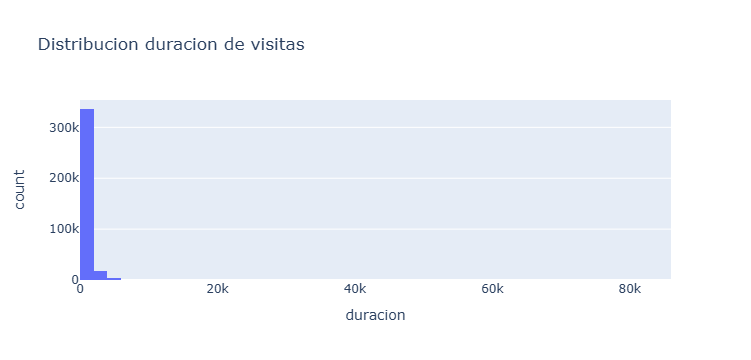

In [50]:
import plotly.express as px
fig = px.histogram(df_visitas, x="duracion", nbins=50, title='Distribucion duracion de visitas')
fig.show()

In [51]:
#Filtrado, sesiones que duraron mas de 0 segundos
sesiones_filtradas=  df_visitas[df_visitas["duracion"] > 0]

In [52]:
#Numero de sesiones que duraron mas de 0 segundos

no_sesiones_dia_f = sesiones_filtradas.groupby(['sesiones_year', 'sesiones_dia']).agg({'Uid': 'count'})
print('Numero promedio de sesiones al dia :', no_sesiones_dia_f.mean())
#Numero de visitas semanales
no_sesiones_semana_f = sesiones_filtradas.groupby(['sesiones_year', 'sesiones_semana']).agg({'Uid': 'count'})
print('Numero promedio de sesiones a la semana :', no_sesiones_semana_f.mean())
#Numero de visitas mensuales
no_sesiones_mes_f = sesiones_filtradas.groupby(['sesiones_year', 'sesiones_mes']).agg({'Uid': 'count'})
print('Numero promedio de sesiones al mes :', no_sesiones_mes_f.mean())


Numero promedio de sesiones al dia : Uid    889.027473
dtype: float64
Numero promedio de sesiones a la semana : Uid    6105.773585
dtype: float64
Numero promedio de sesiones al mes : Uid    26967.166667
dtype: float64


In [53]:
print('La mode es :', df_visitas["duracion"].mode())
print('El minimo es :', df_visitas["duracion"].min())
print('El maximo es :', df_visitas["duracion"].max())

La mode es : 0    60
dtype: int64
El minimo es : 0
El maximo es : 84480


In [54]:
print('Numero de sesiones mayores a 0 segundos :', sesiones_filtradas["Uid"].count())
print('Numero de sesiones iguales a 0 segundos :',(df_visitas[df_visitas["duracion"] == 0])['Uid'].count())

Numero de sesiones mayores a 0 segundos : 323606
Numero de sesiones iguales a 0 segundos : 35794


Se observaron un total de 907.99 de visitantes unicos diarios, y un total de 5716.245283 visitantes unicos a la semana, 23228.416667 al mes, estos valores son muy similares al numero de sesiones diarias, semanales y mensulas(987.36, 6781.13, 29950.0 respectivamente), sin embargo, el la diferencia relativa va aumentanto con forme aumentamos la escala de tiempo, esto sugiere que la mayoria de visitantes no suelen visitar la pagina mas de una vez al dia. Cerca del 10% de las sesiones duraro 0 segundos, no estoy seguro que pueda representar una sesion de 0 segundos, abria que investigar que sucede con estos visitantes

## Parte 2 Ventas


In [55]:
df_ventas['Buy Ts'] = pd.to_datetime(df_ventas['Buy Ts'])

In [56]:
#obtencion primera visita
primera_visita = df_visitas.groupby('Uid')['Start Ts'].min().reset_index()
primera_visita.columns = ['Uid', 'Primer_visita']

#obtencion de primera compra
primera_compra = df_ventas.groupby('Uid')['Buy Ts'].min().reset_index()
primera_compra.columns = ['Uid', 'Primer_compra']

conversion = pd.merge(primera_visita, primera_compra, on='Uid')

In [57]:
print(conversion.head())

                Uid       Primer_visita       Primer_compra
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00
3  2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00


In [58]:
conversion['tiempo_de_conversion'] = (conversion['Primer_compra'] - conversion['Primer_visita']).dt.days
print(conversion.head())

                Uid       Primer_visita       Primer_compra  \
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00   
3  2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00   
4  2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00   

   tiempo_de_conversion  
0                   106  
1                     0  
2                     0  
3                     0  
4                     0  


In [59]:
conversion['tiempo_de_conversion'].describe()

count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: tiempo_de_conversion, dtype: float64

In [60]:
pedidos_mes = df_ventas.groupby(df_ventas['Buy Ts'].dt.to_period('M')).size()

In [61]:
# Convertir a DataFrame
pedidos_mes_df = pedidos_mes.reset_index()
pedidos_mes_df.columns = ['Mes', 'no_ventas']

In [62]:
pedidos_mes_df['Mes'] = pedidos_mes_df['Mes'].astype(str)
print(pedidos_mes_df)

        Mes  no_ventas
0   2017-06       2354
1   2017-07       2363
2   2017-08       1807
3   2017-09       3387
4   2017-10       5679
5   2017-11       5659
6   2017-12       6218
7   2018-01       4721
8   2018-02       5281
9   2018-03       5326
10  2018-04       3273
11  2018-05       4346
12  2018-06          1


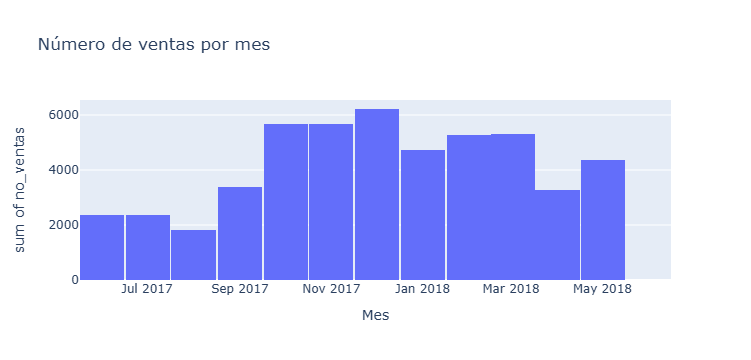

In [63]:
no_ventas_mes = px.histogram(pedidos_mes_df, nbins= 12, x='Mes', y='no_ventas',
                              title='Número de ventas por mes')
no_ventas_mes.show()

In [64]:
compras = df_ventas[df_ventas['Revenue'] >0 ]
compra_promedio = compras['Revenue'].mean()
print('Tamaño promedio de la compra: ', compra_promedio)

Tamaño promedio de la compra:  5.004709713287269


In [65]:
conversion = pd.merge(primera_visita, primera_compra, on='Uid', how='inner')
conversion['MesPrimerVisita'] = conversion['Primer_visita'].dt.to_period('M')

# 4. Agregar la cohorte a las ventas (por Uid)
df_ventas = df_ventas.merge(conversion[['Uid', 'MesPrimerVisita']], on='Uid', how='left')

# 5. Extraer el mes de cada compra
df_ventas['MesCompra'] = df_ventas['Buy Ts'].dt.to_period('M')

# 6. Calcular diferencia de meses desde la adquisición (cohorte)
df_ventas['MesDesdeAdquisicion'] = (df_ventas['MesCompra'] - df_ventas['MesPrimerVisita']).apply(lambda x: x.n)

# 7. Agrupar ingresos por cohorte y mes desde adquisición
cohorte_ltv = df_ventas.groupby(['MesPrimerVisita', 'MesDesdeAdquisicion'])['Revenue'].sum().reset_index()

# 8. Pivotear para obtener tabla LTV
ltv_pivot = cohorte_ltv.pivot(index='MesPrimerVisita', columns='MesDesdeAdquisicion', values='Revenue').fillna(0)

# 9. (Opcional) LTV acumulado por cohorte
ltv_acumulado = ltv_pivot.cumsum(axis=1)

# Mostrar
ltv_acumulado.head()

MesDesdeAdquisicion,0,1,2,3,4,5,6,7,8,9,10,11
MesPrimerVisita,,,,,,,,,,,,
2017-06,9557.49,12222.07,13686.76,17568.85,21509.44,24333.92,27823.87,30094.68,32412.59,35894.23,38098.24,40026.05
2017-07,9874.89,10934.17,12043.07,13026.03,13873.02,14671.10,15259.10,16029.40,16753.92,17344.95,17812.11,17812.11
2017-08,6234.81,7232.13,8233.48,9179.69,9989.73,10522.63,11009.28,12255.51,13086.15,13461.87,13461.87,13461.87
2017-09,12357.20,16057.68,18168.31,28607.24,29895.72,31805.77,32772.61,33263.99,33682.56,33682.56,33682.56,33682.56
2017-10,18362.32,22172.15,23499.17,24557.22,25600.69,26622.88,27201.79,27857.69,27857.69,27857.69,27857.69,27857.69


In [66]:
numero_de_usuarios =  df_ventas['Uid'].nunique()
ventas_totales =df_ventas['Revenue'].sum()

In [67]:
LTV =  ventas_totales/numero_de_usuarios
print(LTV)

6.9013279303452615


In [68]:
print(df_costos.head())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08


In [69]:
df_costos['dt'] = pd.to_datetime(df_costos['dt'])
df_costos['mes'] = df_costos['dt'].dt.to_period('M')

# Total
gasto_total = df_costos['costs'].sum()
print('Gasto total: ', gasto_total)
# Por fuente
gasto_por_fuente = df_costos.groupby('source_id')['costs'].sum()
print('Gasto por fuente: ', gasto_por_fuente)
gasto_fuente = gasto_por_fuente.reset_index()
gasto_fuente.columns = ['Fuente', 'Gasto']
# Por mes
gasto_mensual = df_costos.groupby('mes')['costs'].sum()
print('Gasto mensual: ', gasto_mensual)
gasto_por_mes = gasto_mensual.reset_index()
gasto_por_mes.columns = ['Mes', 'Gasto']


Gasto total:  329131.62
Gasto por fuente:  source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64
Gasto mensual:  mes
2017-06    18015.00
2017-07    18240.59
2017-08    14790.54
2017-09    24368.91
2017-10    36322.88
2017-11    37907.88
2017-12    38315.35
2018-01    33518.52
2018-02    32723.03
2018-03    30415.27
2018-04    22289.38
2018-05    22224.27
Freq: M, Name: costs, dtype: float64


In [70]:
gasto_por_mes['Mes'] = gasto_por_mes['Mes'].astype(str)

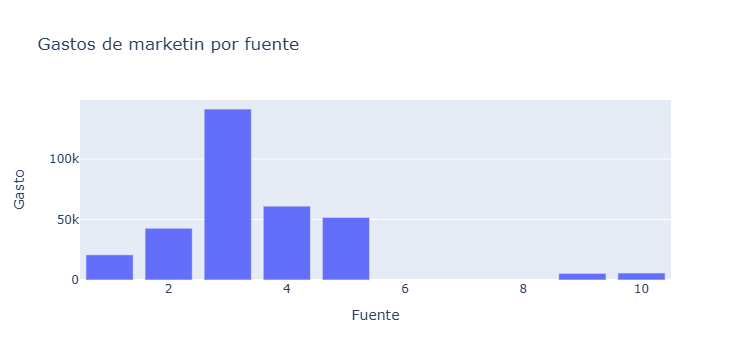

In [71]:
g_fuentes = px.bar(gasto_fuente, x='Fuente', y='Gasto',
                              title='Gastos de marketin por fuente')
g_fuentes.show()

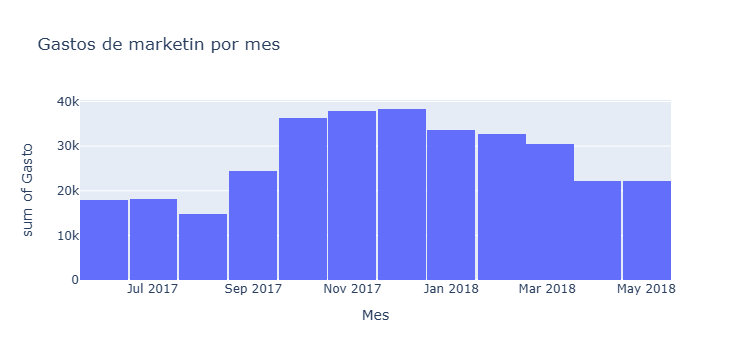

In [72]:
m_gasto = px.histogram(gasto_por_mes, nbins= 12, x='Mes', y='Gasto',
                              title='Gastos de marketin por mes')
m_gasto.show()

In [73]:
# 1. Id de usuarios unicos
usuarios_con_venta = df_ventas['Uid'].unique()

# 2. Visitas con fuente solo de usuarios que compraron
visitas_con_ventas = df_visitas[df_visitas['Uid'].isin(usuarios_con_venta)]

# 3. Usuarios únicos por fuente
usuarios_por_fuente = visitas_con_ventas.groupby('Source Id')['Uid'].nunique().reset_index()
usuarios_por_fuente.columns = ['source_id', 'clientes']

# 4. Costos por fuente
costos_por_fuente = gasto_por_fuente.reset_index()

# 5. Merge y calcular CAC
cac = pd.merge(costos_por_fuente, usuarios_por_fuente, on='source_id', how='left')
cac['CAC'] = cac['costs'] / cac['clientes']

cac['clienteXinversion'] = cac['clientes']/cac['costs'] 

In [74]:
print(cac)

   source_id      costs  clientes        CAC  clienteXinversion
0          1   20833.27      7138   2.918642           0.342625
1          2   42806.04      7305   5.859828           0.170653
2          3  141321.63     13846  10.206676           0.097975
3          4   61073.60     14253   4.284965           0.233374
4          5   51757.10     10156   5.096209           0.196224
5          9    5517.49      2793   1.975471           0.506208
6         10    5822.49      1773   3.283976           0.304509


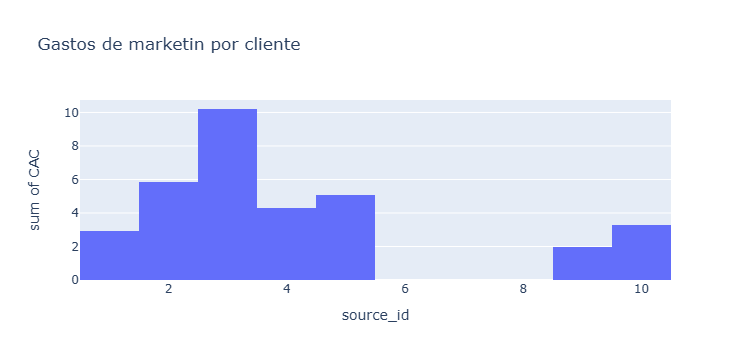

In [75]:
f_cac = px.histogram(cac, nbins= 12, x='source_id', y='CAC',
                              title='Gastos de marketin por cliente')
f_cac.show()

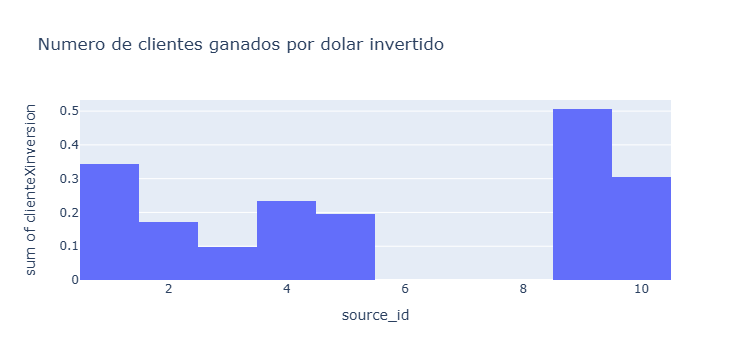

In [76]:
CxI = px.histogram(cac, nbins= 12, x='source_id', y='clienteXinversion',
                              title='Numero de clientes ganados por dolar invertido')
CxI.show()

In [83]:
costos_por_fuente.columns = ['source_id', 'costs']

In [84]:
# 1. Haciendo merge con visitas
ventas_fuente = pd.merge(df_ventas, df_visitas[['Uid', 'Source Id']], on='Uid', how='left')

# 2. Ingresos por fuente
ingresos_por_fuente = ventas_fuente.groupby('Source Id')['Revenue'].sum().reset_index()
ingresos_por_fuente.columns = ['source_id', 'ingresos']

# 3. Merge con costos
romi = pd.merge(costos_por_fuente, ingresos_por_fuente, on='source_id', how='left')

# 4. Calculo del romi

romi['ROMI'] = (romi['ingresos'] - romi['costs']) / romi['costs']



In [85]:
print(romi)

   source_id      costs      ingresos        ROMI
0          1   20833.27  2.298200e+06  109.313944
1          2   42806.04  2.638189e+06   60.631237
2          3  141321.63  2.966880e+05    1.099381
3          4   61073.60  4.966902e+05    7.132649
4          5   51757.10  1.181477e+06   21.827344
5          9    5517.49  3.634225e+04    5.586736
6         10    5822.49  1.461923e+04    1.510821


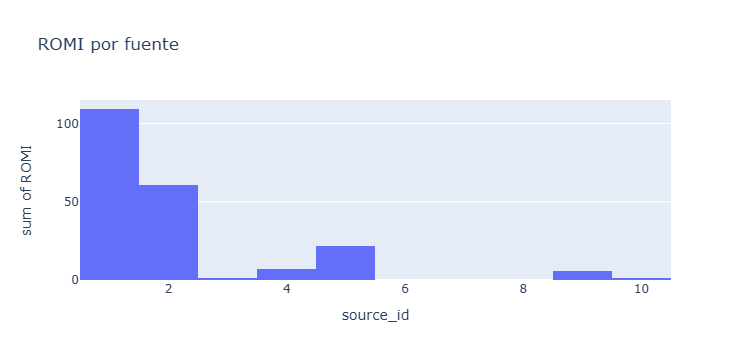

In [86]:
f_romi = px.histogram(romi, nbins= 12, x='source_id', y='ROMI',
                              title='ROMI por fuente')
f_romi.show()

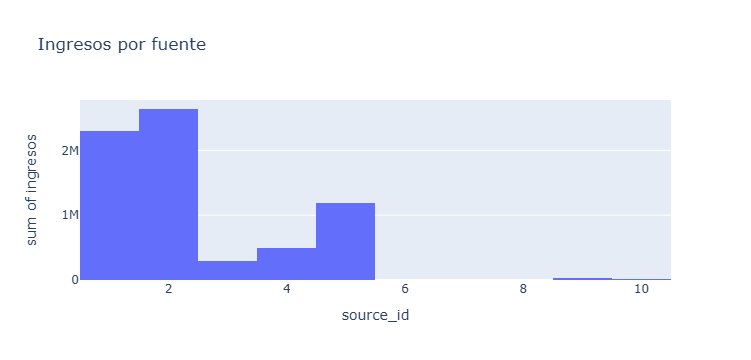

In [87]:
f_romi = px.histogram(romi, nbins= 12, x='source_id', y='ingresos',
                              title='Ingresos por fuente')
f_romi.show()

La mayoria de los usuarios realizaron su primera compra el mismo dia que iniciaron su primera sesion, esto podria correlacionarse con los resultados en el analisis de visitas, donde vimos que la mayoria de los usuarios no ingresaban mas de una vez al mes. Los meses de octubre, diciembre, febrero y abril fueron los meses que generaron mas ventas, y tambien fueron los meses con mayores gastos de marketin, esto seguramente se vea influenciado por las celebraciones que se celebran en esas fechas, y los gastos de marketin elevados podrian verse influenciados como un mecanismo de competencia con las otras empresas por acaparar clientes en las temporadas altas. La estrategia de marketin 3 fue la estrategia mas costosa, generando perdidas, dado que se invertia mas en ella de lo que generaba, sin embargo, a falta de mas informacion, no se puede tomar una desicion cocluyente sobre que hacer con esta tactica de marketin. Se indentificaron dos estrategias de marketin con gran potencial, que valdrian la pena incrementar su inversion en ellas, la estrategia 1 y 9, la estrategia 1 fue la estrategia con mayor ROMI mientras que la estrategia 9 fue la que obtuvo el menor costo por visitante atraido, sin embargo, la inversion dedicada  

Se obtuvó un promedio de 23228 sesiones con un promedio de 29950 sesiones, de las cuales 26967 sesiones duraron mas de un segundo, en promedio, las sesiones duraron 643 segundos, sin emgargo, hubó una gran variacion entre la duracion de la sesiones, presentandose sesiones que iban desde los 0 segundos hasta los 84480 segundos, con una moda de 60 segundos.
En promedio, cada compra se realiza por 5 dolares, cada usuario gasto en promedio 6.9  dolares en total. En el mes de agosto es cuando se recibe un menor numero de compras con 1806 compras, mientras que en los meses de octubre, noviembre, diciembre, frebrero y abril son los meses que se alcanza el mayor numero de ventas, con el mayor pico de numero de ventas en diciembre con 6218 ventas, esto probablente se deba a navidad, esto se correlaciona con los gastos de marquetin que presentaron una tencia similar a la del numero de ventas, presentando sus mayores picos de inversion en octubre, noviembre, diciembre, febrero y abril, y agosto las menor inversion. Sin embargo, esto no necesariamente significa que incrementar los gastos de marketin en los meses de bajas ventas vaya a incrementarlas, es posible que la empresa aumente los gastos de marketin en esas temporadas sabiendo con antelacion que son temporadas altas. 

La estrategia de marketin que atrajo mas clientes fue la estrategia 4 que atrajo a 14253 clientes, seguido de la estrategia 3 que atrajo a 13846, sin embargo, la estrategia 3 fue la mas costosa, costando 141321 dolares, generando perdidas esta estrategia de marketin (Gasto mas de lo que genero), en contraste, la estrategia 9 fue la que obtuvo una mejor CAC, o la que atrajo a mas clientes por dolar invertido, sin embargo, la inversion que se dedico a esta estrategia fue tan baja que la cantidad de dinero que genero es despreciable, la estrategia 1 fue la que obtuvo la ROMI mas alta, dado que genero una gran cantidad de ingresos con poca inversion. La empresa parece rentable, sin embargo, se sugiere incremetar la invercion de la estrategia de marketin 1 y 9, a falta mas informacion se sugiere esto, si 